In [19]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot  as plt


In [6]:
X,y = make_moons(
    n_samples= 300,
    noise= 0.2,
    random_state= 42
)


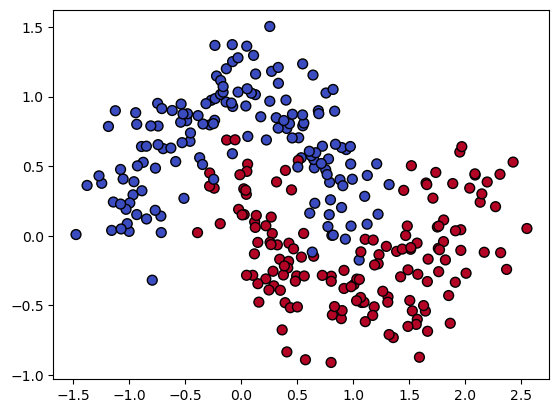

In [ ]:
#make a scatter plot to check the locations 
plt.scatter(
    X[:,0],
    X[:,1],
    c = y ,
    cmap = "coolwarm",
    edgecolors= "k",
    s = 50
)

In [12]:
#split the test train 
from sklearn.model_selection import train_test_split as tts
X_train,X_test,y_train,y_test = tts(
    X,y,
    random_state= 78,
    test_size= 0.32
)

In [13]:
#train the model
from sklearn.svm  import SVC
model = SVC(
    kernel= "poly",
    degree= 3,
    C = 1
)
model.fit(X_train,y_train)

SVC(C=1, kernel='poly')

In [ ]:
y_pred = model.predict(X_test)

In [21]:
#create a mesh grid
x_min,x_max= X[:,0].min() -1, X[:,0].max() + 1
y_min,y_max= X[:,1].min() -1, X[:,1].max() + 1

xx,yy = np.meshgrid(
    np.linspace(x_min,x_max,500),
    np.linspace(y_min,y_max,500)
)

z = model.predict(
    np.c_[xx.ravel(),yy.ravel()]
)
z = z.reshape(xx.shape)

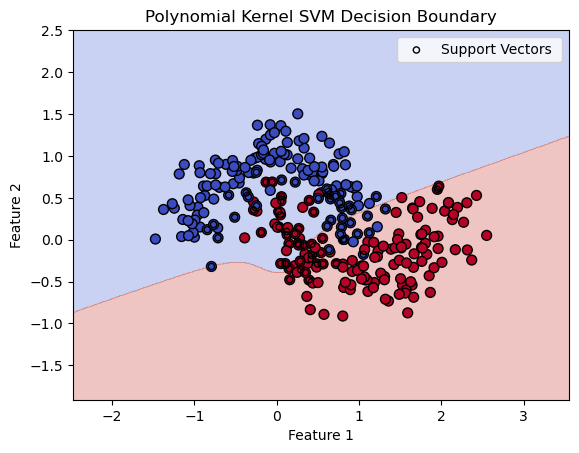

In [34]:
#plot Decision boundary
plt.contourf(
    xx,yy,z,
    alpha = 0.3,
    cmap = "coolwarm"
)
#original data set
plt.scatter(
    X[:,0],
    X[:,1],
    c = y ,
    cmap = "coolwarm",
    edgecolors= "k",
    s = 50
)
#highlight the Support Vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s  = 20,
    facecolors= "none",
    edgecolors= "black",
    linewidths= 1,
    label = "Support Vectors "
)
plt.title("Polynomial Kernel SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
print(f"Accuracy : {acc}")

Accuracy : 0.84375


In [18]:
print(f"Number of Support Vectors : {len(model.support_vectors_)}")

Number of Support Vectors : 75
